# Experiment A — Improved Features (NaiveBayes + Char N-grams)

Isolates feature engineering improvements on top of the `NaiveBayes_Tweets.ipynb` baseline.
Model and architecture are unchanged (ComplementNB). Changes:

| Improvement | Detail |
|---|---|
| **Char n-grams** | Adds a `char_wb` TF-IDF matrix (3–5 char) concatenated with the word matrix |
| **Alpha sweep** | Dev-set sweep over candidate smoothing values to find optimal `alpha` |
| **Wider word n-grams** | Extends from `(1,2)` to `(1,3)` to capture longer phrases |

All results are saved to `experiment_a_results.csv` for cross-notebook comparison.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.naive_bayes import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


## 2. Load & Clean Dataset

In [2]:
DATASET_PATH = 'training.1600000.processed.noemoticon.csv'

df = pd.read_csv(
    DATASET_PATH,
    encoding='latin-1',
    header=None,
    names=['target', 'id', 'date', 'flag', 'user', 'text']
)

df['label'] = df['target'].map({0: 'negative', 4: 'positive'})

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+',    '',      text)
    text = re.sub(r'@\w+',              '',      text)
    text = re.sub(r'#(\w+)',            r'\1',   text)
    text = re.sub(r"n't\b",            ' not',  text)
    text = re.sub(r'(.)\1{2,}',         r'\1\1', text)
    text = re.sub(r'[^\x00-\x7F]+',     '',      text)
    text = re.sub(r'\s+',               ' ',     text).strip().lower()
    return text

df['text_clean'] = df['text'].apply(clean_tweet)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f'Loaded {len(df):,} samples')

Loaded 1,597,119 samples


## 3. Subsample

In [3]:
USE_FULL_DATASET = False
SAMPLE_PER_CLASS = 100_000

if not USE_FULL_DATASET:
    neg = df[df['label'] == 'negative'].sample(n=SAMPLE_PER_CLASS, random_state=42)
    pos = df[df['label'] == 'positive'].sample(n=SAMPLE_PER_CLASS, random_state=42)
    df_work = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df_work = df.copy()

print(f'Working with {len(df_work):,} samples')
print(df_work['label'].value_counts())

Working with 200,000 samples
label
positive    100000
negative    100000
Name: count, dtype: int64


## 4. Train / Dev / Test Split

In [4]:
X = df_work['text_clean']
y = df_work['label']

X_traindev, X_test, y_traindev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_traindev, y_traindev, test_size=0.125, random_state=42, stratify=y_traindev
)

print(f'Train: {len(X_train):,}  |  Dev: {len(X_dev):,}  |  Test: {len(X_test):,}')

Train: 140,000  |  Dev: 20,000  |  Test: 40,000


## 5. Improvement 1 — Alpha Sweep

Finds the optimal Laplace smoothing value using dev-set accuracy.
Uses the word-only vectorizer from the baseline for a fair comparison.

  alpha=0.001   dev_acc=0.7333
  alpha=0.01    dev_acc=0.7348
  alpha=0.05    dev_acc=0.7390
  alpha=0.1     dev_acc=0.7410
  alpha=0.2     dev_acc=0.7457
  alpha=0.3     dev_acc=0.7479
  alpha=0.5     dev_acc=0.7510
  alpha=1.0     dev_acc=0.7562

Best alpha: 1.0


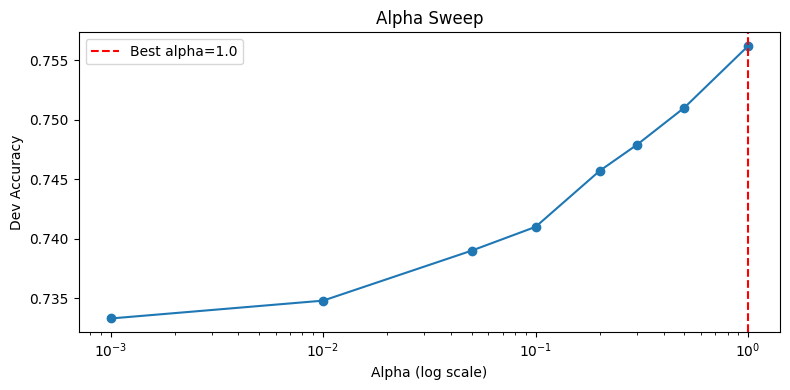

In [5]:
vec_word_base = TfidfVectorizer(
    stop_words='english', ngram_range=(1, 2),
    min_df=2, sublinear_tf=True, max_features=150_000
)
Xtr_base = vec_word_base.fit_transform(X_train)
Xdv_base = vec_word_base.transform(X_dev)

alpha_results = []
for alpha in [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]:
    m = ComplementNB(alpha=alpha)
    m.fit(Xtr_base, y_train)
    acc = accuracy_score(y_dev, m.predict(Xdv_base))
    alpha_results.append({'alpha': alpha, 'dev_accuracy': round(acc, 4)})
    print(f'  alpha={alpha:<6}  dev_acc={acc:.4f}')

alpha_df   = pd.DataFrame(alpha_results)
best_alpha = alpha_df.loc[alpha_df['dev_accuracy'].idxmax(), 'alpha']
print(f'\nBest alpha: {best_alpha}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alpha_df['alpha'], alpha_df['dev_accuracy'], marker='o')
ax.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Dev Accuracy')
ax.set_title('Alpha Sweep')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Improvement 2 — Char N-grams

Adds a `char_wb` TF-IDF matrix (3–5 character n-grams, bounded within word boundaries)
concatenated with the word n-gram matrix.

Char n-grams capture:
- Morphological variants: `sad`, `sadly`, `sadness` share substrings
- Misspellings and informal spellings common in tweets
- Emoji-adjacent patterns left after cleaning

The word vectorizer is also widened to trigrams `(1, 3)` to capture longer phrases.

In [6]:
vec_word = TfidfVectorizer(
    analyzer='word',
    stop_words='english',
    ngram_range=(1, 3),          # widened from (1,2)
    min_df=2,
    sublinear_tf=True,
    max_features=150_000
)

vec_char = TfidfVectorizer(
    analyzer='char_wb',          # bounded within word edges
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True,
    max_features=100_000
)

Xtr_w = vec_word.fit_transform(X_train);  Xdv_w = vec_word.transform(X_dev);  Xte_w = vec_word.transform(X_test)
Xtr_c = vec_char.fit_transform(X_train);  Xdv_c = vec_char.transform(X_dev);  Xte_c = vec_char.transform(X_test)

X_train_combo = hstack([Xtr_w, Xtr_c])
X_dev_combo   = hstack([Xdv_w, Xdv_c])
X_test_combo  = hstack([Xte_w, Xte_c])

print(f'Word vocab:  {len(vec_word.vocabulary_):,}')
print(f'Char vocab:  {len(vec_char.vocabulary_):,}')
print(f'Combined feature matrix shape: {X_train_combo.shape}')

Word vocab:  107,820
Char vocab:  100,000
Combined feature matrix shape: (140000, 207820)


## 7. Train with Best Alpha + Combined Features

In [7]:
model = ComplementNB(alpha=best_alpha)
model.fit(X_train_combo, y_train)
print('Model trained.')

Model trained.


## 8. Evaluate on Dev Set

In [8]:
y_dev_pred = model.predict(X_dev_combo)
print(f'Dev Accuracy: {accuracy_score(y_dev, y_dev_pred):.4f}\n')
print(classification_report(y_dev, y_dev_pred, target_names=['negative', 'positive']))

Dev Accuracy: 0.7739

              precision    recall  f1-score   support

    negative       0.76      0.79      0.78     10000
    positive       0.78      0.75      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



## 9. Final Evaluation on Test Set

Run once after all tuning is complete.

Test Accuracy: 0.7726

              precision    recall  f1-score   support

    negative       0.76      0.79      0.78     20000
    positive       0.78      0.76      0.77     20000

    accuracy                           0.77     40000
   macro avg       0.77      0.77      0.77     40000
weighted avg       0.77      0.77      0.77     40000



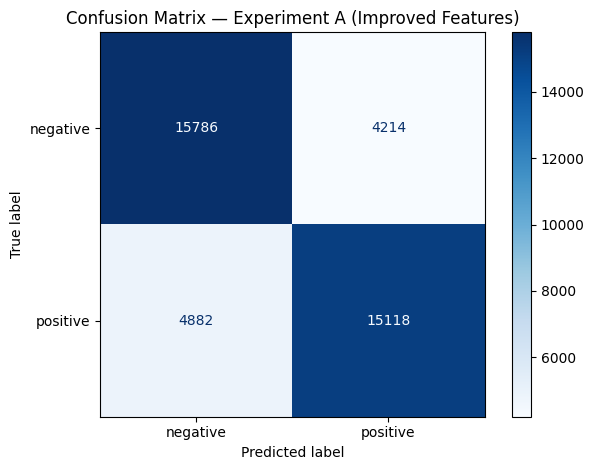

In [9]:
y_test_pred = model.predict(X_test_combo)

print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}\n')
print(classification_report(y_test, y_test_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test, y_test_pred, labels=['negative', 'positive'])
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Experiment A (Improved Features)')
plt.tight_layout()
plt.show()

## 10. Top Discriminative Features

Inspect separately for word and char n-gram vocabularies.

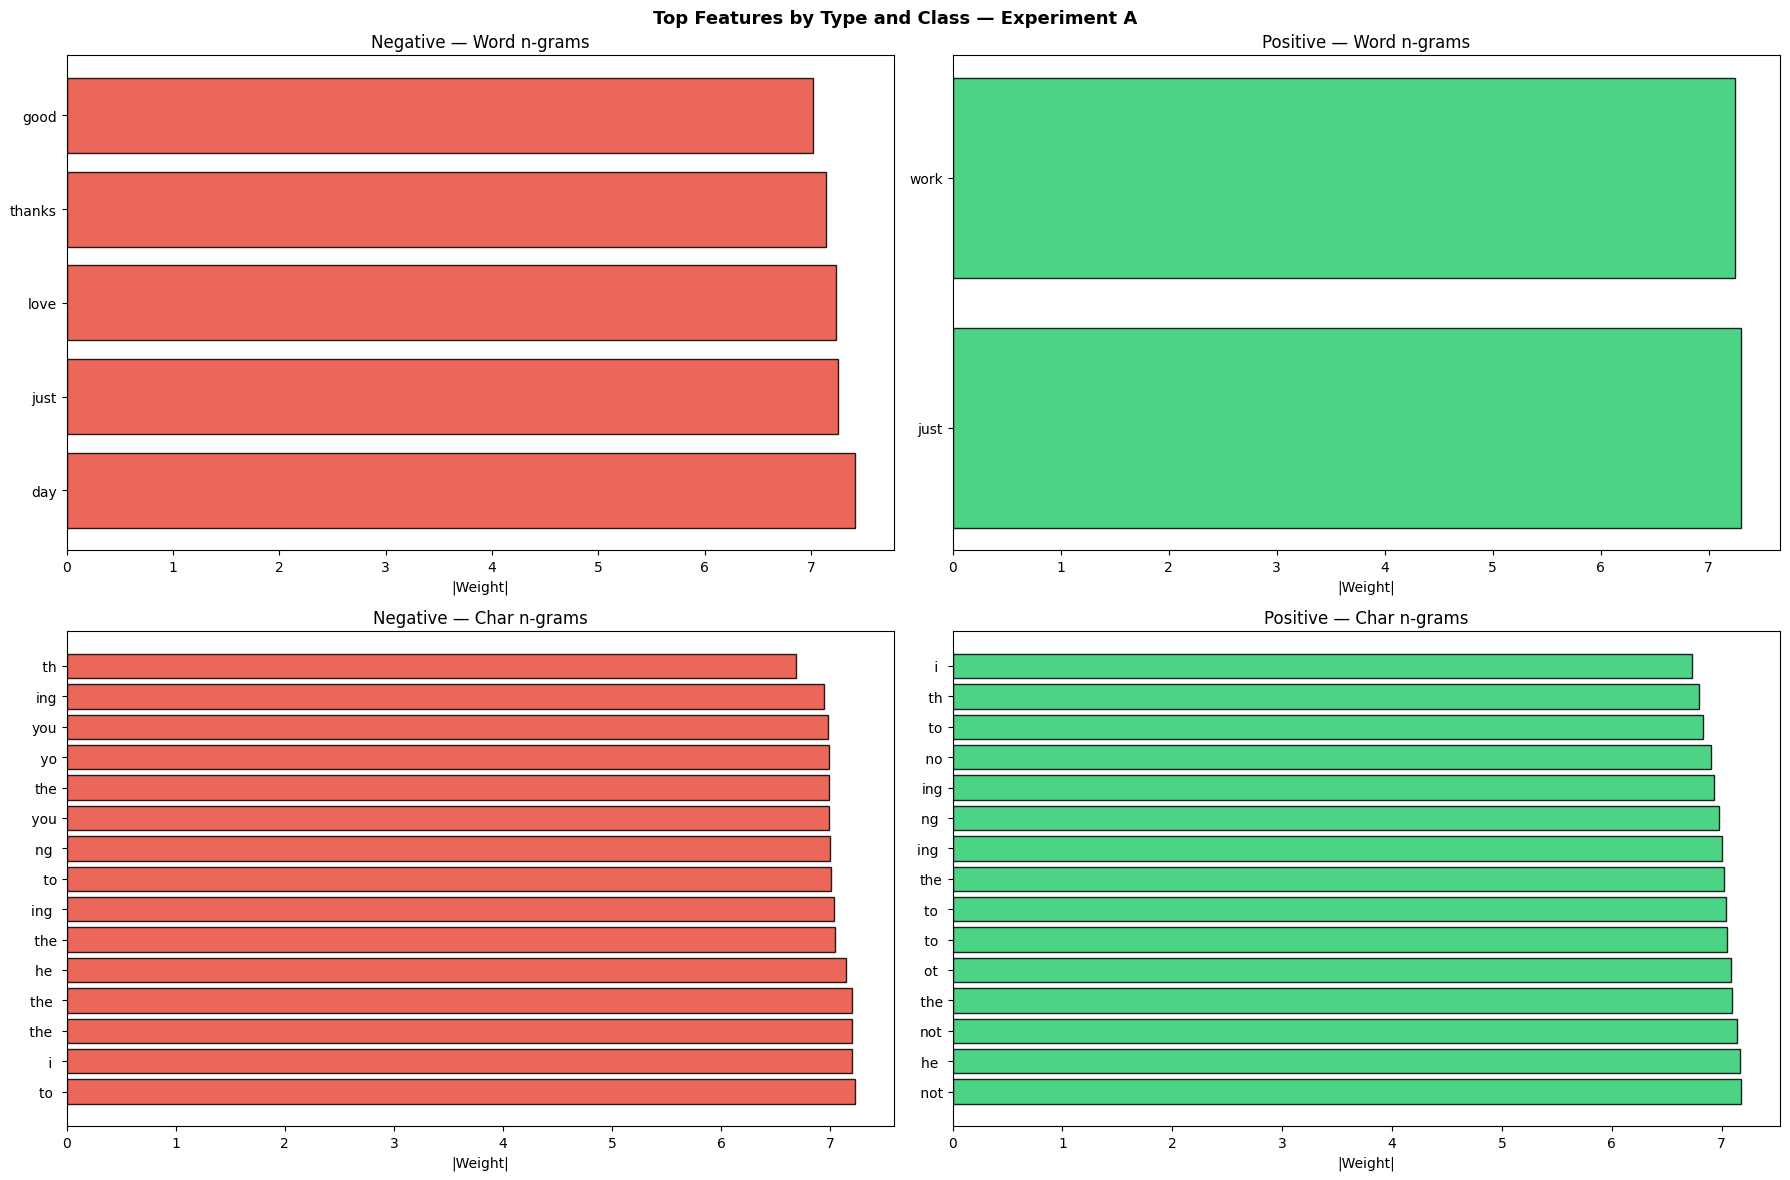

In [10]:
word_vocab_size = len(vec_word.vocabulary_)
all_features    = np.array(
    vec_word.get_feature_names_out().tolist() +
    vec_char.get_feature_names_out().tolist()
)

def top_features_split(model, all_features, word_vocab_size, class_label, n=15):
    class_idx  = list(model.classes_).index(class_label)
    weights    = model.feature_log_prob_[class_idx]
    top_idx    = np.argsort(weights)[:n * 2]
    top_word   = [(all_features[i], weights[i]) for i in top_idx if i < word_vocab_size][:n]
    top_char   = [(all_features[i], weights[i]) for i in top_idx if i >= word_vocab_size][:n]
    return top_word, top_char

colors = {'negative': '#e74c3c', 'positive': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for col, cls in enumerate(['negative', 'positive']):
    top_w, top_c = top_features_split(model, all_features, word_vocab_size, cls, n=15)
    for row, (feats, label) in enumerate([(top_w, 'Word n-grams'), (top_c, 'Char n-grams')]):
        if not feats:
            continue
        words, scores = zip(*feats)
        ax = axes[row][col]
        ax.barh(words[::-1], np.abs(scores[::-1]), color=colors[cls], edgecolor='black', alpha=0.85)
        ax.set_title(f'{cls.capitalize()} — {label}')
        ax.set_xlabel('|Weight|')

plt.suptitle('Top Features by Type and Class — Experiment A', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary

In [11]:
summary = {
    'Experiment':           'A — Improved Features',
    'Model':                'ComplementNB',
    'Best alpha':           best_alpha,
    'Word vocab size':      len(vec_word.vocabulary_),
    'Char vocab size':      len(vec_char.vocabulary_),
    'Training samples':     len(X_train),
    'Test samples':         len(X_test),
    'Dev accuracy':         round(accuracy_score(y_dev, y_dev_pred), 4),
    'Test accuracy':        round(accuracy_score(y_test, y_test_pred), 4),
    'Test F1 (macro)':      round(f1_score(y_test, y_test_pred, average='macro'), 4),
    'Test F1 (negative)':   round(f1_score(y_test, y_test_pred, pos_label='negative', average='binary'), 4),
    'Test F1 (positive)':   round(f1_score(y_test, y_test_pred, pos_label='positive', average='binary'), 4),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print(summary_df.to_string(index=False))
summary_df.to_csv('experiment_a_results.csv', index=False)
print('\nSaved to experiment_a_results.csv')

            Metric                 Value
        Experiment A — Improved Features
             Model          ComplementNB
        Best alpha                   1.0
   Word vocab size                107820
   Char vocab size                100000
  Training samples                140000
      Test samples                 40000
      Dev accuracy                0.7739
     Test accuracy                0.7726
   Test F1 (macro)                0.7725
Test F1 (negative)                0.7763
Test F1 (positive)                0.7687

Saved to experiment_a_results.csv
